# Cross-Sectional Dispersion Analysis

## Origin

Based on updated `/docs/metrics.md` and `/docs/source_bias_findings.md`

## Question

In periods where cross-sectional variance of sentiment across MAG7 increases cross-sectional return dispersion and/or pairwise correlation breakdown increases

## Assumptions

- **Data window**: 2024-02-23 - 2026-02-23
- **Aggregation**: Daily
- **Unit of Analysis**: Article-date

## Data Loading 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from msa.utils.paths import get_joined_dataset, get_processed_data_path
from msa.utils.vars import WINDOW_START, WINDOW_END, MIN_TICKER_COVERAGE, tickers

# Load data
INPUT_PATH = get_joined_dataset()
df = pd.read_csv(
    INPUT_PATH,
    parse_dates=["date", "article_date", "price_date"]
)

print(f"Loaded {len(df):,} rows from {INPUT_PATH.name}")
df.head()

Loaded 12,523 rows from gdelt_ohlcv_join.csv


,seendate,url,title,language,domain,socialimage,company,ticker,date,sentiment_score,sentiment_hits,sentiment_present,article_date,price_date,next_open,next_high,next_low,next_close,next_adj_close,next_volume
0,2024-02-08 00:00:00+00:00,https://www.businesstimes.com.sg/companies-mar...,Arm soars after expansion into new markets buo...,English,businesstimes.com.sg,https://static1.businesstimes.com.sg/s3fs-publ...,Apple,AAPL,2024-02-08,0.91,2.0,True,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
1,2024-02-08 00:45:00+00:00,https://www.hucknalldispatch.co.uk/lifestyle/f...,Dutch Barn Orchard Vodka achieves nationwide l...,English,hucknalldispatch.co.uk,https://www.hucknalldispatch.co.uk/webimg/b25l...,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
2,2024-02-08 00:45:00+00:00,https://www.fool.com/earnings/call-transcripts...,PayPal ( PYPL ) Q4 2023 Earnings Call Transcript,English,fool.com,NaN,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
3,2024-02-08 01:15:00+00:00,https://www.nbcnewyork.com/news/business/money...,"Jim Cramer says recent moves in Apple , Chipot...",English,nbcnewyork.com,https://media.nbcnewyork.com/2023/11/107113454...,Apple,AAPL,2024-02-08,0.00,0.0,False,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200
4,2024-02-08 01:15:00+00:00,https://invezz.com/news/2024/02/07/disney-q1-e...,Disney Q1 earnings : dividend increased as DTC...,English,invezz.com,https://invezz.com/wp-content/uploads/2022/11/...,Apple,AAPL,2024-02-08,-0.76,1.0,True,2024-02-08,2024-02-09,188.649994,189.990005,188.0,188.850006,187.146774,45155200


### Article Date -> Price Date mapping

Sentiment is measured on article publication date
Returns are measured on next available trading day

*Since financial markets close on weekends and holidays, multiple article dates may map to the same trading day (ex. Friday, Saturday, Sunday, Monday (holiday) -> Tuesday price)*

## Data Filtering & Preparation

In [ ]:
print("="*70)
print("DATA FILTERING PIPELINE")
print("="*70)

# Step 1: Initial dataset
print(f"\n1. Initial dataset: {len(df):,} rows")

# Step 2: Filter to MAG7 tickers and date window
df_mag7 = df[
    df["ticker"].isin(tickers)
    & (df["article_date"] >= WINDOW_START)
    & (df["article_date"] <= WINDOW_END)
].copy()
print(f"2. After MAG7 + date filter: {len(df_mag7):,} rows (-{len(df) - len(df_mag7):,})")

# Step 3: Filter to sentiment present
df_mag7_sentiment = df_mag7[df_mag7["sentiment_present"]].copy()
print(f"3. After sentiment_present filter: {len(df_mag7_sentiment):,} rows")

# Step 4: Daily aggregation (article_date × ticker) for sentiment
daily_sentiment = (
    df_mag7_sentiment.groupby(["article_date", "ticker"], as_index=False)["sentiment_score"]
    .mean()
    .rename(columns={"sentiment_score": "mean_sentiment"})
)
print(daily_sentiment.head())
print(f"4. Daily ticker-level sentiment: {len(daily_sentiment):,} rows")

# Step 5: Sentiment dispersion by day (cross-sectional variance, breadth)
def cross_sectional_variance(x):
    return x.var(ddof=0) if len(x) > 1 else 0.0

def sentiment_breadth(x):
    return (x > 0).mean() if len(x) > 0 else 0.0

sentiment_dispersion_all = daily_sentiment.groupby("article_date").agg(
    sent_var=("mean_sentiment", cross_sectional_variance),
    sent_breadth=("mean_sentiment", sentiment_breadth),
    sent_mean=("mean_sentiment", "mean"),
    n_tickers=("ticker", "nunique"),
).reset_index()

# Step 6: Apply coverage filter (>= MIN_TICKER_COVERAGE)
sentiment_dispersion = sentiment_dispersion_all[
    sentiment_dispersion_all["n_tickers"] >= MIN_TICKER_COVERAGE
].copy()
print(f"5. Sentiment dispersion days (>={MIN_TICKER_COVERAGE} tickers): {len(sentiment_dispersion):,} / {len(sentiment_dispersion_all):,}")


DATA FILTERING PIPELINE

1. Initial dataset: 12,523 rows
2. After MAG7 + date filter: 12,319 rows (-204)
3. After sentiment_present filter: 5,286 rows
  article_date ticker  mean_sentiment
0   2024-04-07  GOOGL        0.691250
1   2024-04-07   META        0.496000
2   2024-04-08   AAPL        0.365556
3   2024-04-08   AMZN        0.499375
4   2024-04-08  GOOGL        0.657778
4. Daily ticker-level sentiment: 462 rows
5. Sentiment dispersion days (>=5 tickers): 52 / 100


# Calculations

Core metrics and calculations for testing the hypothesis.

In [ ]:
# Return formula (metrics.md): r_{i,t} = (close - open) / open
df_ret = df_mag7[["price_date", "ticker", "next_open", "next_close"]].drop_duplicates(
    subset=["price_date", "ticker"]
)
df_ret["ret"] = (df_ret["next_close"] - df_ret["next_open"]) / df_ret["next_open"]

# Return dispersion by price_date: std (primary), MAD (secondary), mean
def mad(x):
    return np.abs(x - x.mean()).mean() if len(x) > 0 else np.nan

return_dispersion_all = df_ret.groupby("price_date").agg(
    ret_cs_std=("ret", "std"),
    ret_cs_mad=("ret", mad),
    ret_mean=("ret", "mean"),
    n_tickers_returns=("ticker", "nunique"),
).reset_index()
return_dispersion_all["coverage_ratio"] = return_dispersion_all["n_tickers_returns"] / 7

# Apply coverage filter
return_dispersion = return_dispersion_all[
    return_dispersion_all["n_tickers_returns"] >= MIN_TICKER_COVERAGE
].copy()

# Align sentiment (article_date) with returns (price_date = next trading day)
# Join table maps article_date → price_date (next trading day)
date_map = df_mag7[["article_date", "price_date"]].drop_duplicates()
merged = (
    sentiment_dispersion.merge(date_map, on="article_date", how="inner")
    .merge(return_dispersion, on="price_date", how="inner")
)

print(f"Return dispersion days (>= {MIN_TICKER_COVERAGE} tickers): {len(return_dispersion):,}")
print(f"Aligned sentiment–return pairs: {len(merged):,}")
merged.head()

Return dispersion days (≥5 tickers): 43
Aligned sentiment–return pairs: 52


,article_date,sent_var,sent_breadth,sent_mean,n_tickers,price_date,ret_cs_std,ret_cs_mad,ret_mean,n_tickers_returns,coverage_ratio
0,2024-04-08,0.013287,1.000000,0.535243,7,2024-04-09,0.014713,0.010803,-0.001553,7,1.0
1,2024-07-05,0.038770,1.000000,0.386949,7,2024-07-08,0.013530,0.008924,-0.000446,7,1.0
2,2024-07-08,0.230250,0.857143,0.344937,7,2024-07-09,0.019864,0.013029,0.003720,7,1.0
3,2024-09-06,0.073929,0.571429,0.140048,7,2024-09-09,0.012120,0.007676,-0.001497,7,1.0
4,2024-09-07,0.212878,0.714286,0.137585,7,2024-09-09,0.012120,0.007676,-0.001497,7,1.0


# Test

Evaluate the hypothesis through statistical tests and visualizations.

## Correlation

In [7]:
# Correlation: sentiment dispersion (sent_var) vs return dispersion (ret_cs_std, ret_cs_mad)
corr_std = merged["sent_var"].corr(merged["ret_cs_std"])
corr_mad = merged["sent_var"].corr(merged["ret_cs_mad"])
print(f"Correlation sent_var vs ret_cs_std: {corr_std:.4f}")
print(f"Correlation sent_var vs ret_cs_mad: {corr_mad:.4f}")

Correlation sent_var vs ret_cs_std: 0.1099
Correlation sent_var vs ret_cs_mad: 0.1224


## Visualization

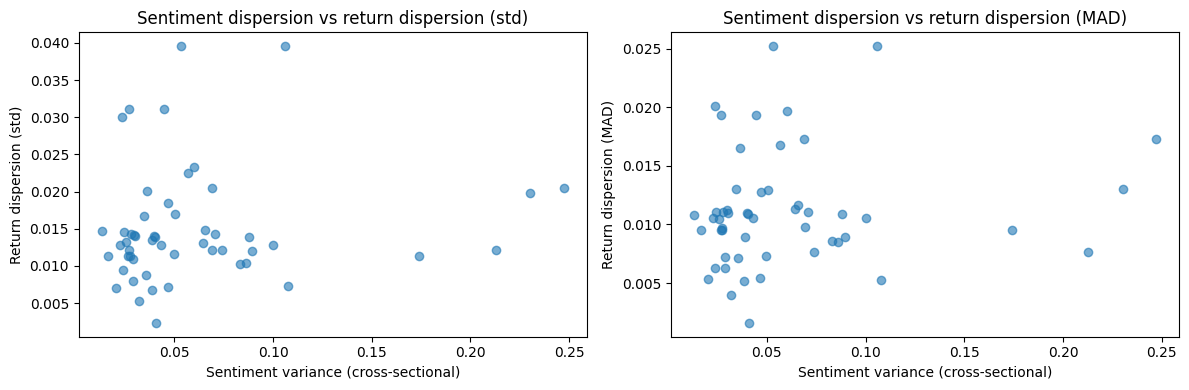

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter plot (sentiment dispersion vs return dispersion)
axes[0].scatter(merged["sent_var"], merged["ret_cs_std"], alpha=0.6)
axes[0].set_xlabel("Sentiment variance (cross-sectional)")
axes[0].set_ylabel("Return dispersion (std)")
axes[0].set_title("Sentiment dispersion vs return dispersion (std)")

axes[1].scatter(merged["sent_var"], merged["ret_cs_mad"], alpha=0.6)
axes[1].set_xlabel("Sentiment variance (cross-sectional)")
axes[1].set_ylabel("Return dispersion (MAD)")
axes[1].set_title("Sentiment dispersion vs return dispersion (MAD)")
plt.tight_layout()
# Display the plot
plt.show()


In [39]:
# Unit test: calculate returns for 5–7 tickers on a sample day, compute ret_cs_std, verify notebook output
import random
random.seed(42)

# Select a random sample day
sample_price_date = random.choice(merged["price_date"].unique())
sample_returns = df_ret[df_ret["price_date"] == sample_price_date]["ret"]
n_tickers = len(sample_returns)

# Assert that the sample day has 5–7 tickers    
assert n_tickers >= 5, f"Sample day has only {n_tickers} tickers (need >= 5)"

# Compute ret_cs_std and ret_cs_mad
computed_std = sample_returns.std()
computed_mad_val = np.abs(sample_returns - sample_returns.mean()).mean()

# Assert that the computed values match the merged dataframe
merged_row = merged[merged["price_date"] == sample_price_date].iloc[0]
# Calculate ret_cs_std and ret_cs_mad from merged dataframe 
ret_cs_std = merged_row["ret_cs_std"]
ret_cs_mad = merged_row["ret_cs_mad"]

# Assert that the computed values match the merged dataframe
np.testing.assert_allclose(computed_std, ret_cs_std, rtol=1e-9)
np.testing.assert_allclose(computed_mad_val, ret_cs_mad, rtol=1e-9)
print(f"Unit test ✓ Sample day {sample_price_date.date()}: {n_tickers} tickers, ret_cs_std={computed_std:.6f}")

Unit test ✓ Sample day 2025-07-07: 7 tickers, ret_cs_std=0.008028


## Conclusion

The data are weakly consistent with the hypothesis: the direction matches the prediction, but the relationship is small and inconclusive.  Larger samples or alternative metrics may provide clearer evidence to support.

## Effect Size

The association is weak (p approx. 0.11)

## Direction

The direction of the sentiment dispersion and return dispersion is positive, based on the correlation calculations.

## Answer to Hypothesis

Based on the relatively low p-value, the hypothesis is neither proven nor disproven (inconclusive)

## Next Steps

- Improve data coverage (potentially with v2 sentiment-scoring)
- Lag + rolling correlation analysis (once data coverage increases (> 100 rows)) to test for structural stability